# **SVM and RF Models**

In [1]:
import mne

In [2]:
from pathlib import Path
import os

# Robust data path setup
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

# Ensure data directory exists
DATA_DIR.mkdir(exist_ok=True)

def load_edf_file(filename):
    """Load an EDF file with helpful error messages."""
    filepath = DATA_DIR / filename
    if not filepath.exists():
        raise FileNotFoundError(
            f"❌ File not found: {filepath}\n"
            f"   Expected location: {DATA_DIR}/\n"
            f"   Available files: {list(DATA_DIR.glob('*.edf')) if DATA_DIR.exists() else 'No data folder'}"
        )
    return str(filepath)

print(f"📁 Data directory: {DATA_DIR}")
print(f"✓ Python working directory: {PROJECT_ROOT}")


📁 Data directory: c:\Users\cbamm\1 Jupyter\ECGR 4116\EEG Final Project\data
✓ Python working directory: c:\Users\cbamm\1 Jupyter\ECGR 4116\EEG Final Project


In [3]:
raw = mne.io.read_raw_edf(load_edf_file("SC4001E0-PSG.edf"), preload=True)
print(raw)

Extracting EDF parameters from c:\Users\cbamm\1 Jupyter\ECGR 4116\EEG Final Project\data\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\cbamm\AppData\Local\Temp\ipykernel_2824\3779514671.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(load_edf_file("SC4001E0-PSG.edf"), preload=True)
C:\Users\cbamm\AppData\Local\Temp\ipykernel_2824\3779514671.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(load_edf_file("SC4001E0-PSG.edf"), preload=True)
C:\Users\cbamm\AppData\Local\Temp\ipykernel_2824\3779514671.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(load_edf_file("SC4001E0-PSG.edf"), preload=True)


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>


In [4]:
annotations = mne.read_annotations(load_edf_file("SC4001EC-Hypnogram.edf"))
print(annotations)

<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>


In [5]:
print(set(annotations.description) )

{np.str_('Sleep stage 4'), np.str_('Sleep stage W'), np.str_('Sleep stage R'), np.str_('Sleep stage 3'), np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage ?')}


In [6]:
raw.pick_channels(['EEG Fpz-Cz'])

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | SC4001E0-PSG.edf, 1 x 7950000 (79500.0 s), ~60.7 MiB, data loaded>

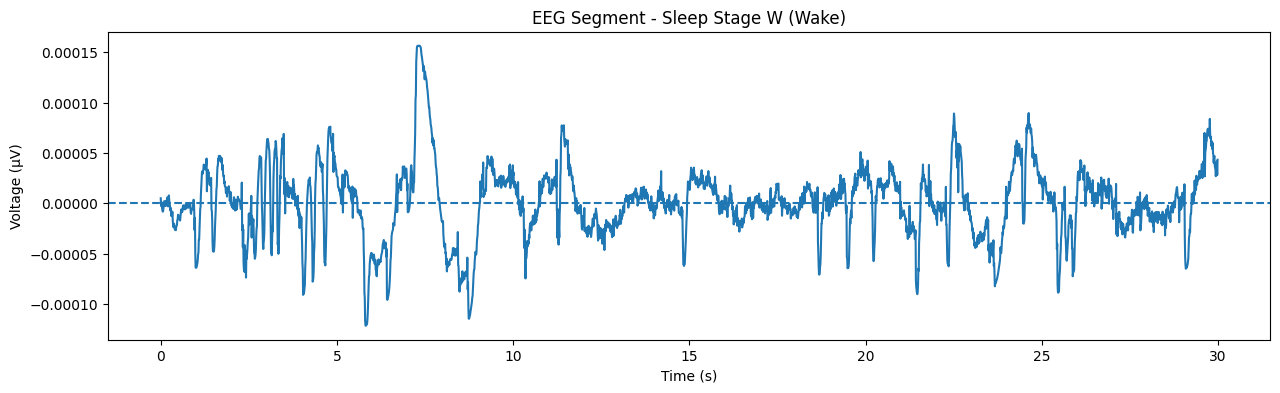

Sleep stage: Sleep stage W


In [7]:
import matplotlib.pyplot as plt

data, times = raw[:]

plt.figure(figsize=(15, 4))  # wider horizontal
plt.plot(times[:3000], data[0][:3000])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV)")
plt.title("EEG Segment - Sleep Stage W (Wake)")
plt.axhline(0, linestyle='--')
plt.show()

start_time = 0  # change if your plot starts elsewhere

for desc, onset, duration in zip(annotations.description,
                                 annotations.onset,
                                 annotations.duration):
    if onset <= start_time < onset + duration:
        print("Sleep stage:", desc)
        break

In [8]:
import numpy as np

sfreq = raw.info['sfreq']
print('Sampling Frequency:', sfreq, 'Hz')

# Map annotation labels to integer class indices
label_map = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 3,  # N3 and N4 are both deep sleep; merge into class 3
    'Sleep stage R': 4,
}

EPOCH_SEC = 30
n_samples = int(EPOCH_SEC * sfreq)  # 3000 samples at 100 Hz

epochs = []
labels = []

for ann in annotations:
    desc = ann['description']
    onset = ann['onset']
    duration = ann['duration']

    # Skip unscored / movement / unknown annotations
    if desc not in label_map:
        continue

    # A single annotation may span multiple 30-second epochs — split them
    n_epochs_in_ann = int(duration // EPOCH_SEC)
    for i in range(n_epochs_in_ann):
        start = int((onset + i * EPOCH_SEC) * sfreq)
        end = start + n_samples

        # Skip if epoch would exceed recording bounds
        if end > data.shape[1]:
            continue

        epoch = data[0, start:end]

        # Skip if the epoch contains NaN or Inf
        if not np.isfinite(epoch).all():
            continue

        epochs.append(epoch)
        labels.append(label_map[desc])

X = np.array(epochs)   # shape: (n_epochs, 3000)
y = np.array(labels)   # shape: (n_epochs,)

stage_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
print(f"Total epochs: {len(X)}")
print(f"Epoch shape: {X.shape}")
print("Class distribution:")
for cls, name in stage_names.items():
    count = np.sum(y == cls)
    print(f"  {name}: {count} epochs ({100 * count / len(y):.1f}%)")


Sampling Frequency: 100.0 Hz
Total epochs: 2650
Epoch shape: (2650, 3000)
Class distribution:
  Wake: 1997 epochs (75.4%)
  N1: 58 epochs (2.2%)
  N2: 250 epochs (9.4%)
  N3: 220 epochs (8.3%)
  REM: 125 epochs (4.7%)


[OK] All epochs are shape (3000,). Labels: [0 1 2 3 4]
[OK] Expected epochs from annotations: 2650, got: 2650
[OK] First epoch matches first annotation onset: True


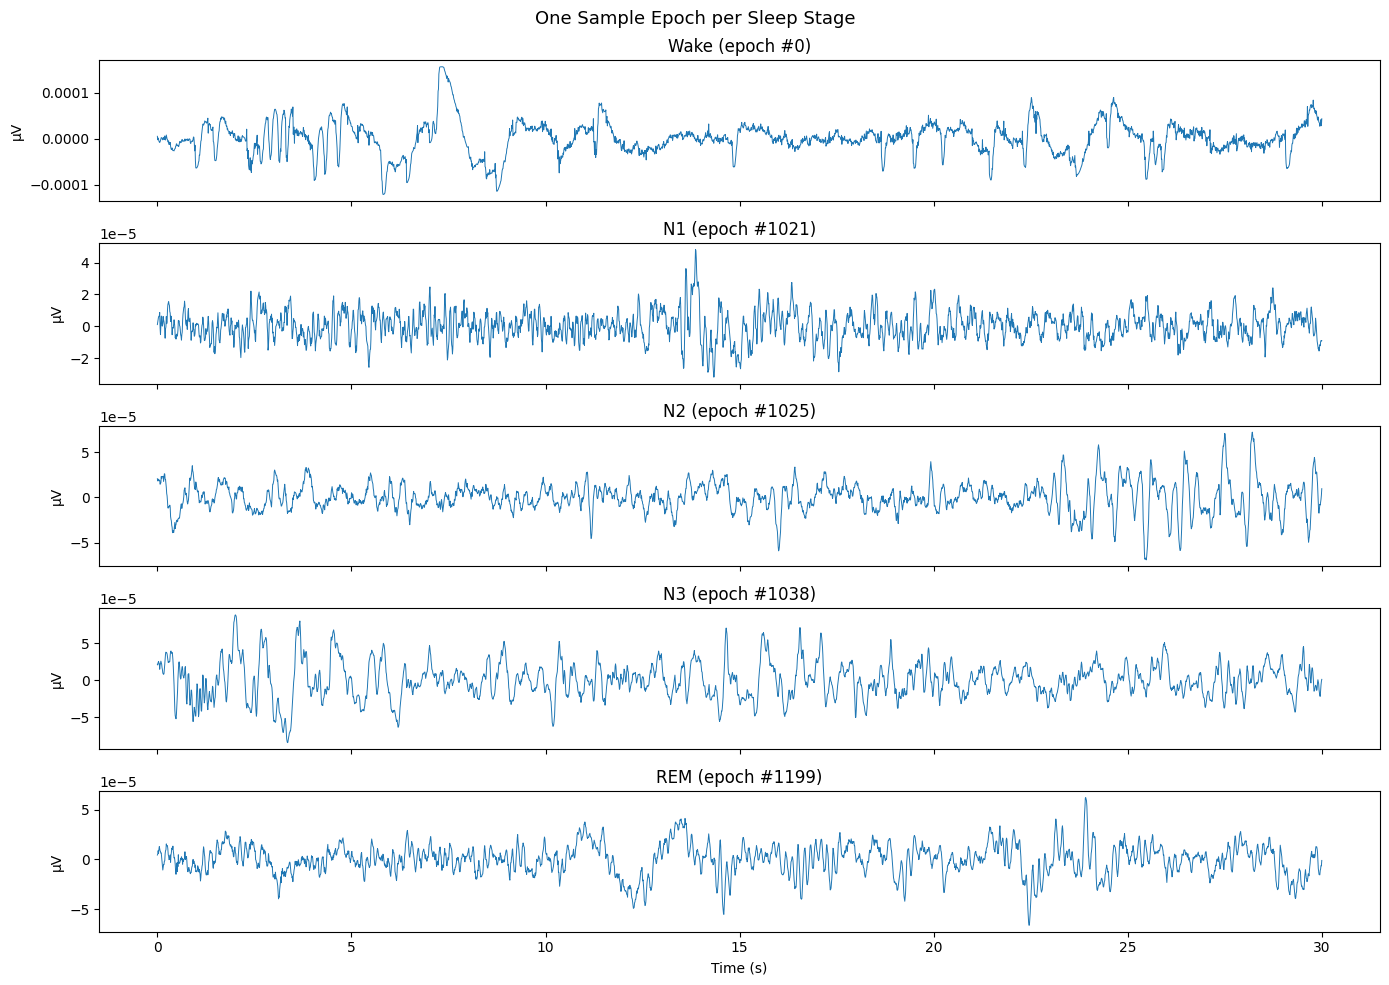

In [16]:
import matplotlib.pyplot as plt

# --- Sanity Check 1: epoch shape and label range ---
assert X.ndim == 2 and X.shape[1] == n_samples, "Epoch shape wrong"
assert set(np.unique(y)).issubset(set(label_map.values())), "Unexpected label found"
print(f"[OK] All epochs are shape (3000,). Labels: {np.unique(y)}")

# --- Sanity Check 2: cross-check epoch count vs annotations ---
expected = sum(
    int(ann['duration'] // EPOCH_SEC)
    for ann in annotations
    if ann['description'] in label_map
)
print(f"[OK] Expected epochs from annotations: {expected}, got: {len(X)}")

# --- Sanity Check 3: verify first epoch onset matches first annotation ---
first_ann = next(a for a in annotations if a['description'] in label_map)
first_start = int(first_ann['onset'] * sfreq)
match = np.allclose(X[0], data[0, first_start:first_start + n_samples])
print(f"[OK] First epoch matches first annotation onset: {match}")

# --- Sanity Check 4: plot one epoch per class ---
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
t = np.linspace(0, EPOCH_SEC, n_samples)

for cls, name in stage_names.items():
    idx = np.where(y == cls)[0]
    ax = axes[cls]
    if len(idx) == 0:
        ax.set_title(f"{name} — no epochs found")
        continue
    ax.plot(t, X[idx[0]], linewidth=0.7)
    ax.set_title(f"{name} (epoch #{idx[0]})")
    ax.set_ylabel("µV")

axes[-1].set_xlabel("Time (s)")
plt.suptitle("One Sample Epoch per Sleep Stage", fontsize=13)
plt.tight_layout()
plt.savefig('epoch_sanity.png')
plt.show()

In [9]:
from scipy import signal
from scipy.stats import skew, kurtosis

def extract_features(epoch, sfreq=100):
    """
    Extract 11 features from a single 30-second EEG epoch.
    
    Features:
      - Band power (5): delta, theta, alpha, sigma, beta
      - Statistics (4): mean, variance, skewness, kurtosis
      - Hjorth (2): mobility, complexity
    """
    # Compute power spectral density using Welch's method
    freqs, psd = signal.welch(epoch, fs=sfreq, nperseg=256)
    
    # Define frequency bands (Hz)
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'sigma': (12, 15),  # sleep spindles
        'beta': (15, 30)
    }
    
    features = {}
    
    # Extract band power (log scale for stability)
    for band_name, (f_min, f_max) in bands.items():
        mask = (freqs >= f_min) & (freqs < f_max)
        power = np.mean(psd[mask])
        features[band_name] = np.log10(power + 1e-10)  # avoid log(0)
    
    # Statistical features
    features['mean'] = np.mean(epoch)
    features['variance'] = np.var(epoch)
    features['skewness'] = skew(epoch)
    features['kurtosis'] = kurtosis(epoch)
    
    # Hjorth parameters (characterize signal complexity)
    # Mobility: standard deviation of the first derivative relative to the signal
    delta_epoch = np.diff(epoch)
    delta_delta_epoch = np.diff(delta_epoch)
    
    mobility = np.std(delta_epoch) / (np.std(epoch) + 1e-10)
    complexity = (np.std(delta_delta_epoch) / (np.std(delta_epoch) + 1e-10)) / (mobility + 1e-10)
    
    features['mobility'] = mobility
    features['complexity'] = complexity
    
    return np.array([features[k] for k in sorted(features.keys())])

# Extract features for all epochs
feature_names = sorted(['delta', 'theta', 'alpha', 'sigma', 'beta', 'mean', 'variance', 'skewness', 'kurtosis', 'mobility', 'complexity'])
X_features = np.array([extract_features(epoch, sfreq) for epoch in X])

print(f"Feature extraction complete.")
print(f"X_features shape: {X_features.shape}")
print(f"Feature names: {feature_names}")
print(f"Feature statistics (mean ± std):")
for i, name in enumerate(feature_names):
    mean = np.mean(X_features[:, i])
    std = np.std(X_features[:, i])
    print(f"  {name:12s}: {mean:7.3f} ± {std:6.3f}")


Feature extraction complete.
X_features shape: (2650, 11)
Feature names: ['alpha', 'beta', 'complexity', 'delta', 'kurtosis', 'mean', 'mobility', 'sigma', 'skewness', 'theta', 'variance']
Feature statistics (mean ± std):
  alpha       :  -9.993 ±  0.003
  beta        :  -9.997 ±  0.002
  complexity  :   4.371 ±  0.928
  delta       :  -9.711 ±  0.132
  kurtosis    :   1.333 ±  1.383
  mean        :   0.000 ±  0.000
  mobility    :   0.356 ±  0.109
  sigma       :  -9.995 ±  0.002
  skewness    :  -0.071 ±  0.346
  theta       :  -9.963 ±  0.016
  variance    :   0.000 ±  0.000


In [10]:
# --- Sanity Check: Feature Extraction ---
print("=" * 70)
print("SANITY CHECK: FEATURE EXTRACTION")
print("=" * 70)

# The 11 features are:
feature_descriptions = {
    'alpha': 'Band power 8-13 Hz (waking, relaxation)',
    'beta': 'Band power 15-30 Hz (waking, focusing)',
    'complexity': 'Hjorth parameter (signal complexity)',
    'delta': 'Band power 0.5-4 Hz (deep sleep)',
    'kurtosis': 'Statistical moment (tail heaviness)',
    'mean': 'Average voltage (signal DC offset)',
    'mobility': 'Hjorth parameter (signal activity)',
    'sigma': 'Band power 12-15 Hz (sleep spindles)',
    'skewness': 'Statistical moment (asymmetry)',
    'theta': 'Band power 4-8 Hz (light sleep, drowsiness)',
    'variance': 'Signal variance (power level)',
}

print("\nThe 11 Features:")
for i, name in enumerate(sorted(feature_descriptions.keys()), 1):
    desc = feature_descriptions[name]
    print(f"  {i:2d}. {name:12s} — {desc}")

# Check 1: All features are finite (no NaN/inf)
print("\n[CHECK 1] All features finite (no NaN/Inf)?")
n_nan = np.sum(~np.isfinite(X_features))
print(f"  NaN/Inf count: {n_nan} (expected: 0)")
assert n_nan == 0, "Found NaN/Inf values in features!"
print("  ✓ PASS")

# Check 2: Band power features should be negative (log10 of power)
print("\n[CHECK 2] Band power features (delta/theta/alpha/sigma/beta) all negative?")
band_features = ['delta', 'theta', 'alpha', 'sigma', 'beta']
band_indices = [feature_names.index(f) for f in band_features]
for idx, name in zip(band_indices, band_features):
    min_val = np.min(X_features[:, idx])
    print(f"  {name:8s}: min={min_val:.3f} (expected: < 0)")
    assert min_val < 0, f"{name} has positive values!"
print("  ✓ PASS")

# Check 3: Delta should be higher during deep sleep (N3) than Wake
print("\n[CHECK 3] Delta power higher in N3 than Wake (N3 has more slow waves)?")
delta_idx = feature_names.index('delta')
delta_wake = np.mean(X_features[y == 0, delta_idx])  # Wake
delta_n3 = np.mean(X_features[y == 3, delta_idx])    # N3
print(f"  Delta in Wake: {delta_wake:.4f}")
print(f"  Delta in N3:   {delta_n3:.4f}")
print(f"  Difference:    {delta_n3 - delta_wake:.4f} (expected: > 0)")
if delta_n3 > delta_wake:
    print("  ✓ PASS (delta is higher in N3, as expected)")
else:
    print("  ⚠ WARNING (delta not clearly higher in N3, may indicate noise or data issue)")

# Check 4: Theta should be higher in N1/N2 than Wake
print("\n[CHECK 4] Theta power higher in N1/N2 than Wake?")
theta_idx = feature_names.index('theta')
theta_wake = np.mean(X_features[y == 0, theta_idx])
theta_n1n2 = np.mean(X_features[(y == 1) | (y == 2), theta_idx])
print(f"  Theta in Wake: {theta_wake:.4f}")
print(f"  Theta in N1/N2: {theta_n1n2:.4f}")
print(f"  Difference:    {theta_n1n2 - theta_wake:.4f} (expected: > 0)")
if theta_n1n2 > theta_wake:
    print("  ✓ PASS (theta higher in N1/N2)")
else:
    print("  ⚠ WARNING")

print("\n" + "=" * 70)
print("Features are ready for model training!")
print("=" * 70)


SANITY CHECK: FEATURE EXTRACTION

The 11 Features:
   1. alpha        — Band power 8-13 Hz (waking, relaxation)
   2. beta         — Band power 15-30 Hz (waking, focusing)
   3. complexity   — Hjorth parameter (signal complexity)
   4. delta        — Band power 0.5-4 Hz (deep sleep)
   5. kurtosis     — Statistical moment (tail heaviness)
   6. mean         — Average voltage (signal DC offset)
   7. mobility     — Hjorth parameter (signal activity)
   8. sigma        — Band power 12-15 Hz (sleep spindles)
   9. skewness     — Statistical moment (asymmetry)
  10. theta        — Band power 4-8 Hz (light sleep, drowsiness)
  11. variance     — Signal variance (power level)

[CHECK 1] All features finite (no NaN/Inf)?
  NaN/Inf count: 0 (expected: 0)
  ✓ PASS

[CHECK 2] Band power features (delta/theta/alpha/sigma/beta) all negative?
  delta   : min=-9.979 (expected: < 0)
  theta   : min=-9.992 (expected: < 0)
  alpha   : min=-9.998 (expected: < 0)
  sigma   : min=-9.999 (expected: < 0)
  

In [11]:
import time
import warnings

def load_all_subjects():
    """
    Load and extract features from all available subjects.
    Automatically finds all SC*E0-PSG.edf (recording) + SC*E(C|H|J)-Hypnogram.edf (hypnogram) pairs.
    Returns combined X_features and y from all subjects.
    """
    from pathlib import Path
    
    # Suppress MNE filter warnings (these are harmless metadata notes from EDF headers)
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    
    start_time = time.time()
    
    # Find all subject pairs
    recordings = sorted(DATA_DIR.glob("SC*E0-PSG.edf"))
    if not recordings:
        raise FileNotFoundError(f"No EDF recordings found in {DATA_DIR}")
    
    print("\n" + "═" * 75)
    print("🔄 MULTI-SUBJECT DATA LOADING")
    print("═" * 75)
    print(f"\n📋 Found {len(recordings)} subject(s) to process:")
    for i, rec in enumerate(recordings, 1):
        subject_id = rec.name.split('E0')[0]
        print(f"   {i}. {subject_id}")
    
    all_X_features = []
    all_y = []
    subject_results = []
    
    for idx, rec_path in enumerate(recordings, 1):
        subject_id = rec_path.name.split('E0')[0]
        subject_start = time.time()
        
        # Find corresponding hypnogram file (may have different suffix: EC, EH, EJ, etc.)
        hypnogram_files = list(DATA_DIR.glob(f"{subject_id}*-Hypnogram.edf"))
        if not hypnogram_files:
            print(f"\n   ❌ [{idx}/{len(recordings)}] {subject_id}: No hypnogram found")
            continue
        
        hyp_path = hypnogram_files[0]
        
        print(f"\n   ⏳ [{idx}/{len(recordings)}] {subject_id}...", end=" ", flush=True)
        
        try:
            # Load data
            raw = mne.io.read_raw_edf(str(rec_path), preload=True, verbose=0)
            annotations = mne.read_annotations(str(hyp_path))
            
            # Extract channel
            raw.pick_channels(['EEG Fpz-Cz'], verbose=0)
            data, _ = raw[:]
            sfreq = raw.info['sfreq']
            
            # Extract epochs
            label_map = {
                'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2,
                'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4,
            }
            EPOCH_SEC = 30
            n_samples = int(EPOCH_SEC * sfreq)
            
            epochs, labels = [], []
            for ann in annotations:
                if ann['description'] not in label_map:
                    continue
                
                onset = ann['onset']
                duration = ann['duration']
                n_epochs_in_ann = int(duration // EPOCH_SEC)
                
                for i in range(n_epochs_in_ann):
                    start = int((onset + i * EPOCH_SEC) * sfreq)
                    end = start + n_samples
                    
                    if end > data.shape[1]:
                        continue
                    
                    epoch = data[0, start:end]
                    if not np.isfinite(epoch).all():
                        continue
                    
                    epochs.append(epoch)
                    labels.append(label_map[ann['description']])
            
            X_subj = np.array(epochs)
            y_subj = np.array(labels)
            
            # Extract features
            X_features_subj = np.array([extract_features(epoch, sfreq) for epoch in X_subj])
            
            elapsed = time.time() - subject_start
            
            # Count class distribution
            stage_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
            class_counts = {cls: np.sum(y_subj == cls) for cls in range(5)}
            
            print(f"✓ ({elapsed:.1f}s)")
            print(f"       → {len(X_subj):5d} epochs | Features: {X_features_subj.shape[1]}")
            print(f"       → Classes: Wake {class_counts[0]:4d} | N1 {class_counts[1]:4d} | N2 {class_counts[2]:4d} | N3 {class_counts[3]:4d} | REM {class_counts[4]:4d}")
            
            all_X_features.append(X_features_subj)
            all_y.append(y_subj)
            subject_results.append((subject_id, len(X_subj), elapsed))
            
        except Exception as e:
            print(f"❌ ({str(e)[:40]}...)")
            continue
    
    if not all_X_features:
        raise ValueError("❌ No subjects loaded successfully")
    
    # Combine all subjects
    X_features_combined = np.vstack(all_X_features)
    y_combined = np.concatenate(all_y)
    
    total_time = time.time() - start_time
    
    # Print summary
    print("\n" + "─" * 75)
    print("📊 COMBINED DATASET SUMMARY")
    print("─" * 75)
    print(f"✓ Successfully loaded: {len(subject_results)} subject(s)")
    print(f"✓ Total epochs: {len(X_features_combined):,}")
    print(f"✓ Feature matrix shape: {X_features_combined.shape}")
    print(f"✓ Total time: {total_time:.1f}s")
    
    print(f"\n📈 Overall class distribution:")
    stage_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
    total_epochs = len(y_combined)
    for cls in sorted(np.unique(y_combined)):
        count = np.sum(y_combined == cls)
        pct = 100 * count / total_epochs
        bar_length = int(pct / 2)
        bar = "█" * bar_length + "░" * (50 - bar_length)
        print(f"   {stage_names[cls]:5s}: {count:5d} ({pct:5.1f}%) {bar}")
    
    print("\n" + "═" * 75 + "\n")
    
    return X_features_combined, y_combined

# Load all subjects
X_features_all, y_all = load_all_subjects()


═══════════════════════════════════════════════════════════════════════════
🔄 MULTI-SUBJECT DATA LOADING
═══════════════════════════════════════════════════════════════════════════

📋 Found 40 subject(s) to process:
   1. SC4001
   2. SC4002
   3. SC4011
   4. SC4012
   5. SC4021
   6. SC4022
   7. SC4031
   8. SC4032
   9. SC4041
   10. SC4042
   11. SC4051
   12. SC4052
   13. SC4061
   14. SC4062
   15. SC4071
   16. SC4072
   17. SC4081
   18. SC4082
   19. SC4091
   20. SC4092
   21. SC4101
   22. SC4102
   23. SC4111
   24. SC4112
   25. SC4121
   26. SC4122
   27. SC4131
   28. SC4141
   29. SC4142
   30. SC4151
   31. SC4152
   32. SC4161
   33. SC4162
   34. SC4171
   35. SC4172
   36. SC4181
   37. SC4182
   38. SC4191
   39. SC4192
   40. SC4201

   ⏳ [1/40] SC4001... 

✓ (7.7s)
       →  2650 epochs | Features: 11
       → Classes: Wake 1997 | N1   58 | N2  250 | N3  220 | REM  125

   ⏳ [2/40] SC4002... ✓ (9.1s)
       →  2829 epochs | Features: 11
       → Classes: Wake 1885 | N1   59 | N2  373 | N3  297 | REM  215

   ⏳ [3/40] SC4011... ✓ (10.7s)
       →  2802 epochs | Features: 11
       → Classes: Wake 1856 | N1  109 | N2  562 | N3  105 | REM  170

   ⏳ [4/40] SC4012... ✓ (14.5s)
       →  2848 epochs | Features: 11
       → Classes: Wake 1824 | N1   92 | N2  660 | N3   96 | REM  176

   ⏳ [5/40] SC4021... ✓ (26.2s)
       →  2804 epochs | Features: 11
       → Classes: Wake 1907 | N1   94 | N2  545 | N3   95 | REM  163

   ⏳ [6/40] SC4022... ✓ (19.3s)
       →  2755 epochs | Features: 11
       → Classes: Wake 1871 | N1  184 | N2  402 | N3  119 | REM  179

   ⏳ [7/40] SC4031... ✓ (18.3s)
       →  2820 epochs | Features: 11
       → Classes: Wake 2008 | N1   61 | N2  485 | N3   57 | REM  209

   ⏳ [8/40] SC4032... ✓ (24.2s)
       →  2732 epoc

In [12]:
from pathlib import Path
from datetime import datetime
import json
import joblib

# ----- Training run organization -----
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
RUNS_DIR = OUTPUTS_DIR / "runs"
LATEST_DIR = OUTPUTS_DIR / "latest"

for p in [OUTPUTS_DIR, RUNS_DIR, LATEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)


def init_run(run_name="sleep_stage_models"):
    """Create a new timestamped run directory each time it is called."""
    now = datetime.now()
    display_ts = now.strftime("%m/%d/%Y %I:%M:%S %p EST")
    folder_ts  = now.strftime("%m-%d-%Y_%I-%M-%S_%p_EST").lower()
    run_id  = f"{folder_ts}_{run_name}"
    run_dir = RUNS_DIR / run_id

    subdirs = {
        "models":    run_dir / "models",
        "metrics":   run_dir / "metrics",
        "plots":     run_dir / "plots",
        "artifacts": run_dir / "artifacts",
    }
    for path in subdirs.values():
        path.mkdir(parents=True, exist_ok=True)

    manifest = {
        "run_id": run_id,
        "created_at": display_ts,
        "n_samples":  int(len(y_all)) if "y_all" in globals() else None,
        "n_features": int(X_features_all.shape[1]) if "X_features_all" in globals() else None,
        "class_distribution": {
            int(c): int((y_all == c).sum()) for c in sorted(set(y_all.tolist()))
        } if "y_all" in globals() else None,
    }
    (run_dir / "run_manifest.json").write_text(
        __import__('json').dumps(manifest, indent=2), encoding="utf-8"
    )
    (LATEST_DIR / "latest_run.txt").write_text(str(run_dir), encoding="utf-8")
    return {
        "run_id":       run_id,
        "run_dir":      run_dir,
        "models_dir":   subdirs["models"],
        "metrics_dir":  subdirs["metrics"],
        "plots_dir":    subdirs["plots"],
        "artifacts_dir":subdirs["artifacts"],
    }


def save_metrics(run_ctx, name, metrics_dict):
    path = run_ctx["metrics_dir"] / f"{name}.json"
    path.write_text(__import__('json').dumps(metrics_dict, indent=2), encoding="utf-8")
    return path


def save_model(run_ctx, name, model_obj):
    path = run_ctx["models_dir"] / f"{name}.joblib"
    joblib.dump(model_obj, path)
    return path


def next_plot_path(run_ctx, name, ext="png"):
    return run_ctx["plots_dir"] / f"{name}.{ext}"


print("Run helpers defined. Training cell will create a new folder each run.")

Run helpers defined. Training cell will create a new folder each run.


In [13]:
import time as _time
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, cohen_kappa_score,
)

# ── New timestamped folder every run ───────────────────────────────────
RUN = init_run("svm_rf_baseline")

X_train, X_val, y_train, y_val = train_test_split(
    X_features_all, y_all, test_size=0.2,
    random_state=42, stratify=y_all, shuffle=True,
)

stage_names = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

models = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    class_weight='balanced', random_state=42)),
    ]),
    'RF': RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample',
        n_jobs=-1, random_state=42,
    ),
}

print('=' * 60)
print('  SLEEP STAGE CLASSIFIER  ─  BASELINE TRAINING')
print('=' * 60)
print(f'  Run     : {RUN["run_id"]}')
print(f'  Dataset : {X_features_all.shape[0]:,} epochs  |  {X_features_all.shape[1]} features')
print(f'  Split   : {X_train.shape[0]:,} train / {X_val.shape[0]:,} val  (80/20)')
print()

all_results = {}  # full results per model
all_metrics = {}  # summary metrics per model

for model_name, model in models.items():
    t0 = _time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    elapsed = _time.time() - t0

    acc      = accuracy_score(y_val, y_pred)
    bal_acc  = balanced_accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    kappa    = cohen_kappa_score(y_val, y_pred)
    precision, recall, f1_each, support = precision_recall_fscore_support(
        y_val, y_pred, labels=[0,1,2,3,4], zero_division=0)
    report_dict = classification_report(
        y_val, y_pred, labels=[0,1,2,3,4],
        target_names=[stage_names[i] for i in range(5)],
        output_dict=True, zero_division=0)

    print(f'  ┌─ {model_name} ({elapsed:.1f}s) ' + '─' * (42 - len(model_name)))
    print(f'  │  Overall Accuracy   {acc*100:6.1f}%')
    print(f'  │  Balanced Accuracy  {bal_acc*100:6.1f}%  ← best metric given class imbalance')
    print(f'  │  Macro F1           {f1_macro*100:6.1f}%')
    print(f'  │  Cohen Kappa         {kappa:5.3f}  (0=random, 1=perfect)')
    print(f'  │')
    print(f'  │  {"Stage":<8} {"Precision":>10} {"Recall":>8} {"F1":>8}')
    print(f'  │  {"-"*38}')
    for i in range(5):
        bar = '█' * int(f1_each[i] * 10) + '░' * (10 - int(f1_each[i] * 10))
        print(f'  │  {stage_names[i]:<8} {precision[i]*100:>9.1f}% {recall[i]*100:>7.1f}% {f1_each[i]*100:>7.1f}%  {bar}')
    print(f'  └' + '─' * 51)
    print()

    cm = confusion_matrix(y_val, y_pred, labels=[0,1,2,3,4])
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=[stage_names[i] for i in range(5)]).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    fig.tight_layout()
    slug = model_name.lower()
    cm_path      = next_plot_path(RUN, f'{slug}_confusion_matrix')
    model_path   = save_model(RUN, slug, model)
    metrics_path = save_metrics(RUN, f'{slug}_metrics', {
        'model': model_name, 'n_train': int(X_train.shape[0]), 'n_val': int(X_val.shape[0]),
        'accuracy': float(acc), 'balanced_accuracy': float(bal_acc),
        'f1_macro': float(f1_macro), 'cohen_kappa': float(kappa),
        'per_class': {stage_names[i]: {
            'precision': float(precision[i]), 'recall': float(recall[i]),
            'f1': float(f1_each[i]), 'support': int(support[i])} for i in range(5)},
        'classification_report': report_dict,
    })
    fig.savefig(cm_path, dpi=140)
    plt.close(fig)
    print(f'  Saved → {model_path.name}  |  {metrics_path.name}  |  {cm_path.name}')
    print()

    all_metrics[model_name] = {'acc': acc, 'bal_acc': bal_acc, 'f1_macro': f1_macro, 'kappa': kappa}
    all_results[model_name] = {
        'precision': precision, 'recall': recall, 'f1': f1_each, 'support': support}

# ────────────────────────────────────────────────────────────
names = list(all_metrics.keys())   # ['SVM', 'RF']

def winner(vals):
    """Return index of the best value, or None if tied."""
    return vals.index(max(vals)) if len(set(vals)) > 1 else None

def fmt_pct(v, is_best): return f'{v*100:5.1f}%' + (' ✓' if is_best else '  ')
def fmt_val(v, is_best): return f'{v:6.3f}' + (' ✓' if is_best else '  ')

print('=' * 70)
print('  MODEL COMPARISON')
print('=' * 70)
print(f'  {"":<28}' + '  '.join(f'{n:>12}' for n in names))
print(f'  {"-"*66}')

# Overall metrics
for metric, label, use_pct in [
    ('acc',      'Overall Accuracy',    True),
    ('bal_acc',  'Balanced Accuracy',   True),
    ('f1_macro', 'Macro F1',            True),
    ('kappa',    'Cohen Kappa',         False),
]:
    vals = [all_metrics[n][metric] for n in names]
    w = winner(vals)
    row = '  '.join(fmt_pct(v, i==w) if use_pct else fmt_val(v, i==w)
                    for i, v in enumerate(vals))
    print(f'  {label:<28} {row}')

# Per-stage F1
print(f'  {"-"*66}')
print(f'  {"Per-Stage F1":<28}' + '  '.join(f'{n:>12}' for n in names))
print(f'  {"-"*66}')
for i in range(5):
    sname = stage_names[i]
    vals = [all_results[n]['f1'][i] for n in names]
    w = winner(vals)
    row = '  '.join(fmt_pct(v, j==w) for j, v in enumerate(vals))
    print(f'  {"  "+sname:<28} {row}')

print('=' * 70)
print(f'  ✓ = better of the two    |   Support (val epochs): Wake {int(all_results[names[0]]["support"][0]):,}  N1 {int(all_results[names[0]]["support"][1]):,}  N2 {int(all_results[names[0]]["support"][2]):,}  N3 {int(all_results[names[0]]["support"][3]):,}  REM {int(all_results[names[0]]["support"][4]):,}')
print('=' * 70)

# Save human-readable baseline_summary.json
summary = {
    "run_id": RUN['run_id'],
    "dataset": {
        "total_epochs": int(X_features_all.shape[0]),
        "n_features": int(X_features_all.shape[1]),
        "train_epochs": int(X_train.shape[0]),
        "val_epochs": int(X_val.shape[0]),
    },
    "models": {
        n: {
            "overall": {
                "accuracy":          f"{all_metrics[n]['acc']*100:.1f}%",
                "balanced_accuracy": f"{all_metrics[n]['bal_acc']*100:.1f}%",
                "macro_f1":          f"{all_metrics[n]['f1_macro']*100:.1f}%",
                "cohen_kappa":       round(all_metrics[n]['kappa'], 3),
            },
            "per_stage_f1": {
                stage_names[i]: f"{all_results[n]['f1'][i]*100:.1f}%" for i in range(5)
            },
        } for n in names
    },
    "winners": {
        label: names[winner([all_metrics[n][metric] for n in names])]
            if winner([all_metrics[n][metric] for n in names]) is not None else 'tie'
        for metric, label in [('acc','overall_accuracy'), ('bal_acc','balanced_accuracy'),
                               ('f1_macro','macro_f1'), ('kappa','cohen_kappa')]
    },
}
save_metrics(RUN, 'baseline_summary', summary)
print(f'\n  baseline_summary.json saved to: {RUN["metrics_dir"]}')
print('=' * 70)

  SLEEP STAGE CLASSIFIER  ─  BASELINE TRAINING
  Run     : 04-29-2026_12-14-19_pm_est_svm_rf_baseline
  Dataset : 109,217 epochs  |  11 features
  Split   : 87,373 train / 21,844 val  (80/20)

  ┌─ SVM (242.4s) ───────────────────────────────────────
  │  Overall Accuracy     86.9%
  │  Balanced Accuracy    79.6%  ← best metric given class imbalance
  │  Macro F1             72.1%
  │  Cohen Kappa         0.757  (0=random, 1=perfect)
  │
  │  Stage     Precision   Recall       F1
  │  --------------------------------------
  │  Wake          98.7%    90.9%    94.6%  █████████░
  │  N1            20.8%    64.9%    31.5%  ███░░░░░░░
  │  N2            93.9%    80.0%    86.4%  ████████░░
  │  N3            77.5%    93.1%    84.6%  ████████░░
  │  REM           58.5%    69.1%    63.4%  ██████░░░░
  └───────────────────────────────────────────────────

  Saved → svm.joblib  |  svm_metrics.json  |  svm_confusion_matrix.png

  ┌─ RF (19.7s) ────────────────────────────────────────
  │  Overal

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# LOSO + SMOTE EVALUATION
# Leave-One-Subject-Out cross-validation: train on N-1 subjects, test on 1.
# SMOTE applied to training fold to fix N1/N3/REM imbalance.
# ═══════════════════════════════════════════════════════════════════════════
import warnings, copy, time as _time
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, cohen_kappa_score,
    precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE

# Suppress noisy sklearn/joblib parallel warning (harmless, not a training failure)
warnings.filterwarnings(
    'ignore',
    category=UserWarning,
    module=r'sklearn\.utils\.parallel',
    message=r'.*sklearn\.utils\.parallel\.delayed.*'
)

# ── Step 1: Load each subject's features separately ──────────────────────
def load_per_subject():
    recordings = sorted(DATA_DIR.glob('SC*E0-PSG.edf'))
    subjects = []
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    label_map = {
        'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2,
        'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4,
    }
    for rec_path in recordings:
        sid = rec_path.name.split('E0')[0]
        hyp = list(DATA_DIR.glob(f'{sid}*-Hypnogram.edf'))
        if not hyp:
            continue
        try:
            r = mne.io.read_raw_edf(str(rec_path), preload=True, verbose=0)
            ann = mne.read_annotations(str(hyp[0]))
            r.pick_channels(['EEG Fpz-Cz'], verbose=0)
            d, _ = r[:]
            sf = r.info['sfreq']
            ns = int(30 * sf)
            eps, lbs = [], []
            for a in ann:
                if a['description'] not in label_map:
                    continue
                for k in range(int(a['duration'] // 30)):
                    s = int((a['onset'] + k * 30) * sf)
                    e = s + ns
                    if e > d.shape[1]:
                        continue
                    ep = d[0, s:e]
                    if not np.isfinite(ep).all():
                        continue
                    eps.append(ep)
                    lbs.append(label_map[a['description']])
            Xs = np.array([extract_features(ep, sf) for ep in eps])
            ys = np.array(lbs)
            subjects.append((sid, Xs, ys))
            stage_ns = {0:'W',1:'N1',2:'N2',3:'N3',4:'R'}
            dist = '  '.join(f'{stage_ns[c]}:{(ys==c).sum()}' for c in range(5))
            print(f'  {sid}: {len(ys):4d} epochs  [{dist}]')
        except Exception as ex:
            print(f'  Skipped {sid}: {ex}')
    return subjects

print('═'*65)
print('  LOSO + SMOTE EVALUATION')
print('  (Leave-One-Subject-Out: train on N-1 subjects, test on 1)')
print('═'*65)
print('\nStep 1 — Loading per-subject data...')
_t0 = _time.time()
subjects = load_per_subject()
print(f'\n  {len(subjects)} subjects loaded in {_time.time()-_t0:.0f}s')

# ── Step 2: SMOTE strategy ────────────────────────────────────────────────
# Bring N1/N3/REM up to match N2 (second-most-common class) in training fold.
# Wake and N2 are left unchanged. class_weight='balanced' handles remaining bias.
def smote_strategy(y_tr):
    n2 = int((y_tr == 2).sum())
    return {c: n2 for c in [1, 3, 4] if (y_tr == c).sum() < n2}

# ── Step 3: LOSO loop ─────────────────────────────────────────────────────
def make_models():
    return {
        'SVM': Pipeline([
            ('sc', StandardScaler()),
            ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                        class_weight='balanced', random_state=42)),
        ]),
        'RF': RandomForestClassifier(
            n_estimators=300, class_weight='balanced_subsample',
            n_jobs=-1, random_state=42,
        ),
    }

stage_names = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
n_folds = len(subjects)
fold_results = {m: [] for m in make_models()}
fold_cm      = {m: np.zeros((5,5), dtype=int) for m in make_models()}

RUN_LOSO = init_run('loso_smote')

print(f'\nStep 2 — LOSO training ({n_folds} folds)...')
print(f'  (SMOTE: N1/N3/REM oversampled to match N2 count in each fold)\n')

for fold_i, (test_sid, X_test, y_test) in enumerate(subjects):
    train_idx = [j for j in range(n_folds) if j != fold_i]
    X_tr = np.vstack([subjects[j][1] for j in train_idx])
    y_tr = np.concatenate([subjects[j][2] for j in train_idx])

    strat = smote_strategy(y_tr)
    smote = SMOTE(sampling_strategy=strat, random_state=42, k_neighbors=5)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

    n_add = len(y_tr_sm) - len(y_tr)
    print(f'  Fold {fold_i+1}/{n_folds} — test: {test_sid}  '
          f'train: {len(y_tr):,} → {len(y_tr_sm):,} (+{n_add:,} SMOTE)')

    for m_name, mdl in make_models().items():
        t0 = _time.time()
        mdl.fit(X_tr_sm, y_tr_sm)
        y_pred = mdl.predict(X_test)
        elapsed = _time.time() - t0

        acc = accuracy_score(y_test, y_pred)
        bal = balanced_accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)
        kap = cohen_kappa_score(y_test, y_pred)
        pr, rc, f1e, sup = precision_recall_fscore_support(
            y_test, y_pred, labels=[0,1,2,3,4], zero_division=0)

        fold_results[m_name].append({
            'subject': test_sid, 'acc': acc, 'bal': bal,
            'f1m': f1m, 'kap': kap, 'f1_per': f1e, 'sup': sup,
        })
        fold_cm[m_name] += confusion_matrix(y_test, y_pred, labels=[0,1,2,3,4])
        print(f'      {m_name}: Acc={acc*100:.1f}%  Bal={bal*100:.1f}%  '
              f'F1={f1m*100:.1f}%  κ={kap:.3f}  ({elapsed:.1f}s)')
    print()

# ── Step 4: Print results ─────────────────────────────────────────────────
avg = {}
for m_name, folds in fold_results.items():
    avg[m_name] = {
        'acc': np.mean([f['acc'] for f in folds]),
        'bal': np.mean([f['bal'] for f in folds]),
        'f1m': np.mean([f['f1m'] for f in folds]),
        'kap': np.mean([f['kap'] for f in folds]),
        'f1_per': np.mean(np.vstack([f['f1_per'] for f in folds]), axis=0),
        'std_acc': np.std([f['acc'] for f in folds]),
        'std_bal': np.std([f['bal'] for f in folds]),
    }

names = list(make_models().keys())

def _w(vals):
    return vals.index(max(vals)) if len(set(round(v,4) for v in vals)) > 1 else None
def _fp(v, best): return f'{v*100:5.1f}%' + (' ✓' if best else '  ')

print('═'*70)
print('  LOSO MEAN RESULTS  (averaged over all subjects ± std)')
print('═'*70)
print(f'  {"":<28}' + '  '.join(f'{n:>14}' for n in names))
print(f'  {"-"*66}')
for metric, label in [('acc','Overall Accuracy'),('bal','Balanced Accuracy'),
                       ('f1m','Macro F1'),('kap','Kappa')]:
    vals = [avg[n][metric] for n in names]
    w = _w(vals)
    if metric == 'kap':
        row = '  '.join(f'{v:6.3f}' + (' ✓' if i==w else '  ')
                        for i, v in enumerate(vals))
    else:
        std_key = 'std_acc' if metric == 'acc' else 'std_bal' if metric == 'bal' else None
        if std_key:
            row = '  '.join(
                f'{v*100:5.1f}%±{avg[n][std_key]*100:4.1f}' + (' ✓' if i==w else '  ')
                for i, (n, v) in enumerate(zip(names, vals)))
        else:
            row = '  '.join(_fp(v, i==w) for i, v in enumerate(vals))
    print(f'  {label:<28} {row}')

print(f'  {"-"*66}')
print(f'  {"Per-Stage F1":<28}' + '  '.join(f'{n:>14}' for n in names))
print(f'  {"-"*66}')
for i in range(5):
    vals = [avg[n]['f1_per'][i] for n in names]
    w = _w(vals)
    row = '  '.join(_fp(v, j==w) for j, v in enumerate(vals))
    print(f'  {"  "+stage_names[i]:<28} {row}')
print('═'*70)

# ── Baseline vs LOSO comparison ───────────────────────────────────────────
if 'all_metrics' in globals() and all('acc' in v for v in all_metrics.values()):
    print('\n  HONEST CHECK: Baseline (random split) vs LOSO')
    print(f'  {"-"*66}')
    print(f'  {"Model":<8} {"Metric":<20} {"Baseline":>10} {"LOSO":>10} {"Change":>8}')
    print(f'  {"-"*56}')
    bmap = {'acc': 'acc', 'bal': 'bal_acc', 'f1m': 'f1_macro'}
    for m in names:
        if m not in all_metrics: continue
        for lk, label in [('acc','Accuracy'),('bal','Bal. Acc'),('f1m','Macro F1')]:
            bk = bmap[lk]
            base_v = all_metrics[m].get(bk, None)
            if base_v is None: continue
            loso_v = avg[m][lk]
            delta = (loso_v - base_v) * 100
            sign = '+' if delta >= 0 else ''
            print(f'  {m:<8} {label:<20} {base_v*100:>9.1f}%  {loso_v*100:>9.1f}%  {sign}{delta:.1f}%')
    print('═'*70)

# ── Save confusion matrices ────────────────────────────────────────────────
for m_name in names:
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(
        fold_cm[m_name],
        display_labels=[stage_names[i] for i in range(5)]
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'LOSO Confusion Matrix — {m_name}  (all folds combined)')
    fig.tight_layout()
    cm_path = next_plot_path(RUN_LOSO, f'{m_name.lower()}_loso_confusion_matrix')
    fig.savefig(cm_path, dpi=140)
    plt.close(fig)

# ── Save JSON summary ─────────────────────────────────────────────────────
loso_summary = {
    'run_id': RUN_LOSO['run_id'],
    'method': 'Leave-One-Subject-Out (LOSO) + SMOTE on training folds',
    'n_subjects': n_folds,
    'smote_strategy': 'N1/N3/REM oversampled to match N2 count in each fold',
    'models': {
        n: {
            'mean_overall': {
                'accuracy':          f"{avg[n]['acc']*100:.1f}% ± {avg[n]['std_acc']*100:.1f}%",
                'balanced_accuracy': f"{avg[n]['bal']*100:.1f}% ± {avg[n]['std_bal']*100:.1f}%",
                'macro_f1':          f"{avg[n]['f1m']*100:.1f}%",
                'cohen_kappa':       round(avg[n]['kap'], 3),
            },
            'mean_per_stage_f1': {
                stage_names[i]: f"{avg[n]['f1_per'][i]*100:.1f}%" for i in range(5)
            },
            'per_fold': [{
                'subject': f['subject'],
                'accuracy': f"{f['acc']*100:.1f}%",
                'balanced_accuracy': f"{f['bal']*100:.1f}%",
                'macro_f1': f"{f['f1m']*100:.1f}%",
                'cohen_kappa': round(f['kap'], 3),
                'per_stage_f1': {stage_names[i]: f"{f['f1_per'][i]*100:.1f}%" for i in range(5)},
            } for f in fold_results[n]],
        } for n in names
    },
}
save_metrics(RUN_LOSO, 'loso_summary', loso_summary)
print(f'\n  Confusion matrices + loso_summary.json saved to:')
print(f'  {RUN_LOSO["run_dir"]}')
print('═'*70)

═════════════════════════════════════════════════════════════════
  LOSO + SMOTE EVALUATION
  (Leave-One-Subject-Out: train on N-1 subjects, test on 1)
═════════════════════════════════════════════════════════════════

Step 1 — Loading per-subject data...
  SC4001: 2650 epochs  [W:1997  N1:58  N2:250  N3:220  R:125]
  SC4002: 2829 epochs  [W:1885  N1:59  N2:373  N3:297  R:215]
  SC4011: 2802 epochs  [W:1856  N1:109  N2:562  N3:105  R:170]
  SC4012: 2848 epochs  [W:1824  N1:92  N2:660  N3:96  R:176]
  SC4021: 2804 epochs  [W:1907  N1:94  N2:545  N3:95  R:163]
  SC4022: 2755 epochs  [W:1871  N1:184  N2:402  N3:119  R:179]
  SC4031: 2820 epochs  [W:2008  N1:61  N2:485  N3:57  R:209]
  SC4032: 2732 epochs  [W:1957  N1:45  N2:400  N3:131  R:199]
  SC4041: 2569 epochs  [W:1534  N1:166  N2:620  N3:53  R:196]
  SC4042: 2788 epochs  [W:1773  N1:137  N2:514  N3:94  R:270]
  SC4051: 2722 epochs  [W:2258  N1:44  N2:217  N3:135  R:68]
  SC4052: 2804 epochs  [W:1780  N1:114  N2:616  N3:114  R:180]
 